### Code to convert COM transport coefficients to SOL reference 
Madeline Murphy


In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import MDAnalysis as mda
import importlib
import glob 
import gc
import os

import warnings
warnings.filterwarnings("ignore")

/Users/maddymurphy/miniconda3/envs/md_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def create_mda(path, data_file, dcd_file, cat_dcd=False):
    if cat_dcd:  
        all_dcd_files = glob.glob(path + dcd_file)
        step = []
        for f in all_dcd_files:
            step.append(int(f.replace('.','_').split('_')[-2]))
        dcd_file = [x for _,x in sorted(zip(step,all_dcd_files))]
        # print(dcd_file)
    else:
        dcd_file = path + dcd_file
    run = mda.Universe(path + data_file,dcd_file, format="LAMMPS", atom_style='id resid type x y z')
    
    atom_names = {'1': 'O',
              '2': 'H',
              '3': 'C',
              '4': 'N_NO',
              '5': 'O_NO'}

    names = []
    for atom in run.atoms:
        names.append(atom_names[atom.type])
    run.add_TopologyAttr('name', names)
    
    return run

In [13]:
# load lij from the com reference frame
# finite size effects
concentrations = ['1M', '0.5M', '0.1M', '0.01M']
conc_vals = [1.0, 0.5, 0.1, 0.01]  # molality values for the concentrations
Mw = {'Cs': 132.91, 'K': 39.10, 'Na': 22.99, 'Li': 6.94, 'NO3': 62.00, 'H2O': 18.01528}  # g/mol
cations = ['Cs', 'K', 'Na', 'Li']
sizes = ['0', '1', '2', '3']
lij_names = ['Cation self', 'Anion self', 'Cation total', 'Anion total', 'Cation-Anion distinct']

lij_com = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)), dtype=object)
beta = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)), dtype=object)
avg_lij_com = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))
std_lij_com = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))

# lij_sol = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)), dtype=object)
avg_lij_sol = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))
std_lij_sol = np.empty((len(cations), len(concentrations), len(lij_names), len(sizes)))

avg_cond_com = np.empty((len(cations), len(concentrations), len(sizes)))
std_cond_com = np.empty((len(cations), len(concentrations), len(sizes)))
avg_cond_sol = np.empty((len(cations), len(concentrations), len(sizes)))
std_cond_sol = np.empty((len(cations), len(concentrations), len(sizes)))

avg_t_sol = np.empty((len(cations), len(concentrations), len(sizes)))
std_t_sol = np.empty((len(cations), len(concentrations), len(sizes)))
avg_t_sol_computed = np.empty((len(cations), len(concentrations), len(sizes)))
std_t_sol_computed = np.empty((len(cations), len(concentrations), len(sizes)))

box_sizes_all = np.empty((len(cations), len(concentrations), len(sizes)))

def com_to_sol(lij, w_frac):
    L_com = np.zeros((2,2))
    L_sol = np.zeros((2,2))
    L_com[0,0] = lij[2] # cation total
    L_com[1,1] = lij[3] # anion total
    L_com[0,1] = lij[4] # cation-anion 
    L_com[1,0] = lij[4] # cation-anion 

    # create the transformation matrix
    U = np.zeros((2,2))
    U[0,0] = 1 + (w_frac[0]/w_frac[2])
    U[1,1] = 1 + (w_frac[1]/w_frac[2])
    U[0,1] = (w_frac[1]/w_frac[2])
    U[1,0] = (w_frac[0]/w_frac[2])

    L_sol = U @ L_com @ U.T
    return np.array([L_sol[0,0], L_sol[1,1], L_sol[0,0], L_sol[1,1], L_sol[0,1]], dtype=float)

def cond(lij):
    return lij[2] + lij[3] - 2*lij[4]

def t_sol_from_com(t_com, w_frac):
    term1 = (1/w_frac[2]) * t_com
    term2 = w_frac[1] * (1/w_frac[2]) 
    return term1 - term2

def transference(lij):
    return (lij[2] - lij[4]) / (lij[2] + lij[3] - 2*lij[4])


folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/'
figure_folder = f'/Users/maddymurphy/Documents/caltech/phd/research-projects/nitrate-reduction/supporting-elyte-sims/figures/'

for k, cation in enumerate(cations):
    for j, conc in enumerate(concentrations):
        for s, size in enumerate(sizes):
            if s == 0:
                # determine mass fraction of each component -- same for each replicate
                path = f'{folder}simulations/{cation}/{conc}/rep1/'
                u = create_mda(
                    path,
                    data_file="system.data",
                    dcd_file="nvt_unwrapped_*.dcd",
                    cat_dcd=True,)
                
                n_cat = len(u.select_atoms('name C'))
                n_ani = len(u.select_atoms('name N_NO'))
                n_wat = len(u.select_atoms('name O'))

                m_cat = n_cat * Mw[cation]
                m_ani = n_ani * Mw['NO3']
                m_wat = n_wat * Mw['H2O']
                total_mass = m_cat + m_ani + m_wat

                w_frac = [m_cat/total_mass, m_ani/total_mass, m_wat/total_mass] # mass fractions of cation, anion, water

                lij_all = np.load(f'{folder}data/{cation}/{conc}/total-transport/lij.npy')
                lij_beta_all = np.load(f'{folder}data/{cation}/{conc}/total-transport/beta.npy')

                for i in range(len(lij_names)):
                    lij_com[k,j,i,s] = lij_all[i,:]
                    beta[k,j,i,s] = lij_beta_all[i,:]

                lij_sol = np.zeros_like(lij_all, dtype=float)
                c_sol = np.zeros(len(lij_all[0,:]), dtype=float)
                c_com = np.zeros(len(lij_all[0,:]), dtype=float)
                t_sol = np.zeros(len(lij_all[0,:]), dtype=float)
                t_sol_computed = np.zeros(len(lij_all[0,:]), dtype=float)
                for rep in range(len(lij_all[0,:])):
                    lij_sol[:,rep] = com_to_sol(lij_all[:,rep], w_frac)
                    c_sol[rep] = cond(lij_sol[:,rep])
                    c_com[rep] = cond(lij_all[:,rep])
                    t_sol[rep] = transference(lij_sol[:,rep])
                    t_sol_computed[rep] = t_sol_from_com(transference(lij_all[:,rep]), w_frac)

                np.save(f'{folder}data/{cation}/{conc}/total-transport/lij_sol.npy', lij_sol)

                avg_lij_com[k,j,:,s] = np.mean(lij_all, axis=1)
                std_lij_com[k,j,:,s] = np.std(lij_all, axis=1)
                avg_lij_sol[k,j,:,s] = np.mean(lij_sol, axis=1)
                std_lij_sol[k,j,:,s] = np.std(lij_sol, axis=1)
                avg_cond_com[k,j,s] = np.mean(c_com)
                std_cond_com[k,j,s] = np.std(c_com)
                avg_cond_sol[k,j,s] = np.mean(c_sol)
                std_cond_sol[k,j,s] = np.std(c_sol)

                avg_t_sol[k,j,s] = np.mean(t_sol)
                std_t_sol[k,j,s] = np.std(t_sol)
                avg_t_sol_computed[k,j,s] = np.mean(t_sol_computed)
                std_t_sol_computed[k,j,s] = np.std(t_sol_computed)

            else:
                path = f'{folder}simulations/{cation}/{conc}/finite-size/box{size}/rep0/'
                u = create_mda(
                    path,
                    data_file="system.data",
                    dcd_file="nvt_unwrapped_*.dcd",
                    cat_dcd=True,)
                
                n_cat = len(u.select_atoms('name C'))
                n_ani = len(u.select_atoms('name N_NO'))
                n_wat = len(u.select_atoms('name O'))

                m_cat = n_cat * Mw[cation]
                m_ani = n_ani * Mw['NO3']
                m_wat = n_wat * Mw['H2O']
                total_mass = m_cat + m_ani + m_wat

                w_frac = [m_cat/total_mass, m_ani/total_mass, m_wat/total_mass] # mass fractions of cation, anion, water


                lij_all = np.load(f'{folder}data/{cation}/{conc}/finite-size/box{size}/total-transport/lij.npy')
                lij_beta_all = np.load(f'{folder}data/{cation}/{conc}/finite-size/box{size}/total-transport/beta.npy')

                for i in range(len(lij_names)):
                    lij_com[k,j,i,s] = lij_all[i,:]
                    beta[k,j,i,s] = lij_beta_all[i,:]
                    if conc == '0.01M':
                        print(f'Box size {size} for {cation} {conc} has beta values: {lij_beta_all[i,:]}')

                lij_sol = np.zeros_like(lij_all, dtype=float)
                c_sol = np.zeros(len(lij_all[0,:]), dtype=float)
                c_com = np.zeros(len(lij_all[0,:]), dtype=float)
                t_sol = np.zeros(len(lij_all[0,:]), dtype=float)
                t_sol_computed = np.zeros(len(lij_all[0,:]), dtype=float)

                for rep in range(len(lij_all[0,:])):
                    lij_sol[:,rep] = com_to_sol(lij_all[:,rep], w_frac)
                    c_sol[rep] = cond(lij_sol[:,rep])
                    c_com[rep] = cond(lij_all[:,rep])
                    t_sol[rep] = transference(lij_sol[:,rep])
                    t_sol_computed[rep] = t_sol_from_com(transference(lij_all[:,rep]), w_frac)

                np.save(f'{folder}data/{cation}/{conc}/finite-size/box{size}/total-transport/lij_sol.npy', lij_sol)

                avg_lij_com[k,j,:,s] = np.mean(lij_all, axis=1)
                std_lij_com[k,j,:,s] = np.std(lij_all, axis=1)
                avg_lij_sol[k,j,:,s] = np.mean(lij_sol, axis=1)
                std_lij_sol[k,j,:,s] = np.std(lij_sol, axis=1)
                avg_cond_sol[k,j,s] = np.mean(c_sol)
                std_cond_sol[k,j,s] = np.std(c_sol)
                avg_cond_com[k,j,s] = np.mean(c_com)
                std_cond_com[k,j,s] = np.std(c_com)

                avg_t_sol[k,j,s] = np.mean(t_sol)
                std_t_sol[k,j,s] = np.std(t_sol)
                avg_t_sol_computed[k,j,s] = np.mean(t_sol_computed)
                std_t_sol_computed[k,j,s] = np.std(t_sol_computed)

            # read in the box sizes
            box_sizes = np.load(f'{folder}simulations/{cation}/{conc}/finite-size/box{size}/box_sizes.npy')
            avg_box_size = np.mean(box_sizes)

            box_sizes_all[k,j,s] = avg_box_size

Box size 1 for Cs 0.01M has beta values: [0.98783035 0.95233198 1.00224744]
Box size 1 for Cs 0.01M has beta values: [1.01763385 0.9881898  0.97295116]
Box size 1 for Cs 0.01M has beta values: [0.96813384 0.94851008 0.97730091]
Box size 1 for Cs 0.01M has beta values: [0.99136154 0.98618328 0.95067286]
Box size 1 for Cs 0.01M has beta values: [1.74428582 0.46019617 0.45110463]
Box size 2 for Cs 0.01M has beta values: [0.99645177 0.97039851 0.98165806]
Box size 2 for Cs 0.01M has beta values: [0.9843375  0.99414726 0.99574669]
Box size 2 for Cs 0.01M has beta values: [1.03862944 0.99779679 0.99992772]
Box size 2 for Cs 0.01M has beta values: [0.96341487 1.00342488 1.04324586]
Box size 2 for Cs 0.01M has beta values: [1.45429165 2.91254166 1.65258989]
Box size 3 for Cs 0.01M has beta values: [1.0031591  0.98711161 0.99085565]
Box size 3 for Cs 0.01M has beta values: [1.01509677 0.96682927 1.01257989]
Box size 3 for Cs 0.01M has beta values: [0.93766938 1.01530172 0.96330115]
Box size 3 f

----------------
### SI Figures

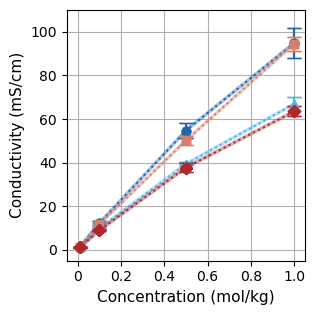

In [14]:
# plot conductivity comparison
fig, ax = plt.subplots(1,1, figsize=(3.25,3.25))
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
markers = ['o', 's', '^', 'D']
cation_labels = [r'Cs$^+$', r'K$^+$', r'Na$^+$', r'Li$^+$']

for i, cation in enumerate(cations):
    ax.plot(conc_vals, avg_cond_com[i,:,0], marker=markers[i], color=colors[i],linestyle='-', linewidth=2.5, alpha=0.4)
    ax.errorbar(conc_vals, avg_cond_com[i,:,0], yerr=std_cond_com[i,:,0], fmt=markers[i], color=colors[i], capsize=5)

    ax.plot(conc_vals, avg_cond_sol[i,:,0], marker=markers[i], color=colors[i], linestyle=':', label=cation_labels[i], linewidth=1.5)
    ax.errorbar(conc_vals, avg_cond_sol[i,:,0], yerr=std_cond_sol[i,:,0], fmt=markers[i], color=colors[i], capsize=5)

ax.set_xlabel('Concentration (mol/kg)', fontsize=11)
ax.set_ylabel(r'Conductivity (mS/cm)', fontsize=11)

ax.set_xlim(-0.05, 1.05)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)

ax.set_ylim(-5, 110)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(['0', '20', '40', '60', '80', '100'], fontsize=10)

# ax.legend(frameon=False, fontsize=9, loc='lower right', ncols=2)
ax.grid()
plt.tight_layout()

fig.savefig(f'{figure_folder}si/conductivity_comparison.png', dpi=300)

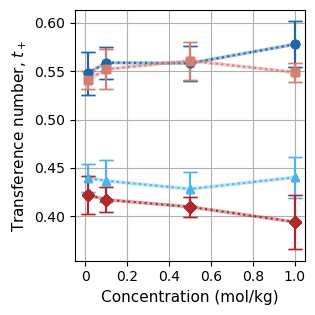

In [17]:
# plot t+ comparison
fig, ax = plt.subplots(1,1, figsize=(3.25,3.25))
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
markers = ['o', 's', '^', 'D']
cation_labels = [r'Cs$^+$', r'K$^+$', r'Na$^+$', r'Li$^+$']

for i, cation in enumerate(cations):
    ax.plot(conc_vals, avg_t_sol_computed[i,:,0], marker=markers[i], color=colors[i], linestyle='-', linewidth=2.5, alpha=0.4)
    ax.errorbar(conc_vals, avg_t_sol_computed[i,:,0], yerr=std_t_sol_computed[i,:,0], fmt=markers[i], color=colors[i], capsize=5)

    ax.plot(conc_vals, avg_t_sol[i,:,0], marker=markers[i], color=colors[i], linestyle=':', label=cation_labels[i], linewidth=1.5)
    ax.errorbar(conc_vals, avg_t_sol[i,:,0], yerr=std_t_sol[i,:,0], fmt=markers[i], color=colors[i], capsize=5)

ax.set_xlabel('Concentration (mol/kg)', fontsize=11)
ax.set_ylabel(r'Transference number, $t_+$', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
# ax.set_ylim(-0.05, 1.05)
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
# ax.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
# ax.legend(frameon=False, fontsize=9, loc='lower right', ncols=2)
ax.grid()
plt.tight_layout()
fig.savefig(f'{figure_folder}si/tplus_comparison.png', dpi=300)

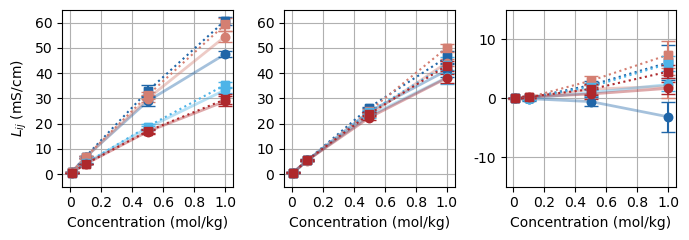

In [65]:
# plot lij vs lij_sol for box size 1
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
fig, ax = plt.subplots(1,3, figsize=(7,2.5))

for i, cation in enumerate(cations):
    ax[0].plot(conc_vals, avg_lij_com[i,:,2,0], color=colors[i], marker='o', linestyle='-', label=cation, alpha=0.4, linewidth=2.0)
    ax[0].errorbar(conc_vals, avg_lij_com[i,:,2,0], yerr=std_lij_com[i,:,2,0], color=colors[i], fmt='o', capsize=5)

    ax[0].plot(conc_vals, avg_lij_sol[i,:,2,0], color=colors[i], marker='s', linestyle=':')
    ax[0].errorbar(conc_vals, avg_lij_sol[i,:,2,0], yerr=std_lij_sol[i,:,2,0], color=colors[i], fmt='s', capsize=5)

    ax[1].plot(conc_vals, avg_lij_com[i,:,3,0], color=colors[i], marker='o', linestyle='-', label=cation, alpha=0.4, linewidth=2.0)
    ax[1].errorbar(conc_vals, avg_lij_com[i,:,3,0], yerr=std_lij_com[i,:,3,0], color=colors[i], fmt='o', capsize=5)
    ax[1].plot(conc_vals, avg_lij_sol[i,:,3,0], color=colors[i], marker='s', linestyle=':')
    ax[1].errorbar(conc_vals, avg_lij_sol[i,:,3,0], yerr=std_lij_sol[i,:,3,0], color=colors[i], fmt='s', capsize=5)

    ax[2].plot(conc_vals, avg_lij_com[i,:,4,0], color=colors[i], marker='o', linestyle='-', label=cation, alpha=0.4, linewidth=2.0)
    ax[2].errorbar(conc_vals, avg_lij_com[i,:,4,0], yerr=std_lij_com[i,:,4,0], color=colors[i], fmt='o', capsize=5)
    ax[2].plot(conc_vals, avg_lij_sol[i,:,4,0], color=colors[i], marker='s', linestyle=':')
    ax[2].errorbar(conc_vals, avg_lij_sol[i,:,4,0], yerr=std_lij_sol[i,:,4,0], color=colors[i], fmt='s', capsize=5)

for i in range(3):
    ax[i].set_xlabel('Concentration (mol/kg)')
    ax[i].set_xlim((-0.05,1.05))
    ax[i].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax[i].set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
    ax[i].grid()

    ax[0].set_ylabel(r'$L_{ij}$ (mS/cm)')

    if i != 2:
        ax[i].set_ylim((-5,65))
        ax[i].set_yticks([0, 10, 20, 30, 40, 50, 60])
        ax[i].set_yticklabels(['0', '10', '20', '30', '40', '50', '60'], fontsize=10)
    else:
        ax[i].set_ylim((-15,15))
        ax[i].set_yticks([-10, 0, 10])
        ax[i].set_yticklabels(['-10', '0', '10'], fontsize=10)

plt.tight_layout()
fig.savefig(f'{figure_folder}si/transport-com-to-sol-comparison.png', dpi=300)


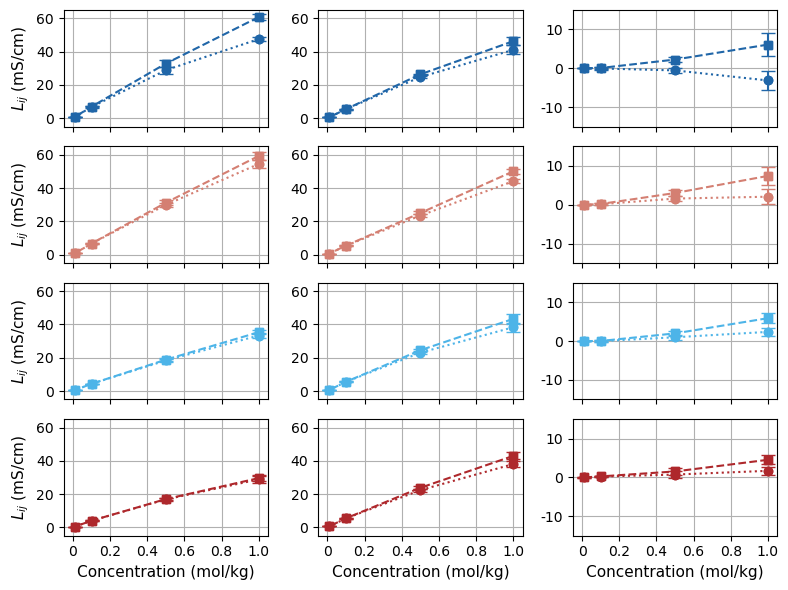

In [45]:
# plot lij vs lij_sol for box size 1
colors = ["#2066a8", "#d47f72",  "#4db4e8", "#ae282c"]
fig, ax = plt.subplots(4,3, figsize=(8,6), sharex=True)

for i, cation in enumerate(cations):
    ax[i,0].plot(conc_vals, avg_lij_com[i,:,2,0], color=colors[i], marker='o', linestyle=':', label=cation)
    ax[i,0].errorbar(conc_vals, avg_lij_com[i,:,2,0], yerr=std_lij_com[i,:,2,0], color=colors[i], fmt='o', capsize=5)

    ax[i,0].plot(conc_vals, avg_lij_sol[i,:,2,0], color=colors[i], marker='s', linestyle='--')
    ax[i,0].errorbar(conc_vals, avg_lij_sol[i,:,2,0], yerr=std_lij_sol[i,:,2,0], color=colors[i], fmt='s', capsize=5)

    ax[i,1].plot(conc_vals, avg_lij_com[i,:,3,0], color=colors[i], marker='o', linestyle=':', label=cation)
    ax[i,1].errorbar(conc_vals, avg_lij_com[i,:,3,0], yerr=std_lij_com[i,:,3,0], color=colors[i], fmt='o', capsize=5)
    ax[i,1].plot(conc_vals, avg_lij_sol[i,:,3,0], color=colors[i], marker='s', linestyle='--')
    ax[i,1].errorbar(conc_vals, avg_lij_sol[i,:,3,0], yerr=std_lij_sol[i,:,3,0], color=colors[i], fmt='s', capsize=5)

    ax[i,2].plot(conc_vals, avg_lij_com[i,:,4,0], color=colors[i], marker='o', linestyle=':', label=cation)
    ax[i,2].errorbar(conc_vals, avg_lij_com[i,:,4,0], yerr=std_lij_com[i,:,4,0], color=colors[i], fmt='o', capsize=5)
    ax[i,2].plot(conc_vals, avg_lij_sol[i,:,4,0], color=colors[i], marker='s', linestyle='--')
    ax[i,2].errorbar(conc_vals, avg_lij_sol[i,:,4,0], yerr=std_lij_sol[i,:,4,0], color=colors[i], fmt='s', capsize=5)

    for j in range(3):
        ax[-1,j].set_xlabel('Concentration (mol/kg)', fontsize=11)
        ax[i,j].set_xlim((-0.05,1.05))
        ax[i,j].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax[i,j].set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
        ax[i,j].grid()

        ax[i,0].set_ylabel(r'$L_{ij}$ (mS/cm)', fontsize=11)

        if j != 2:
            ax[i,j].set_ylim((-5,65))
            ax[i,j].set_yticks([0, 20, 40, 60])
            ax[i,j].set_yticklabels(['0', '20', '40', '60'], fontsize=10)
        else:
            ax[i,j].set_ylim((-15,15))
            ax[i,j].set_yticks([-10, 0, 10])
            ax[i,j].set_yticklabels(['-10', '0', '10'], fontsize=10)

plt.tight_layout()
fig.savefig(f'{figure_folder}si/transport-com-to-sol-comparison-by-cation.png', dpi=300)
